# User Satisfaction Analysis

**Goals:**
1. Engagement & experience scores (Euclidean distance from reference clusters)
2. Satisfaction score + top 10 customers
3. Regression model to predict satisfaction
4. K-means (k=2) on scores
5. Export to **MySQL** + experiment tracking

> Requires: PostgreSQL (xDR data) + MySQL (`docker compose up -d`)

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root / "src") not in sys.path:
    sys.path.insert(0, str(project_root / "src"))

# Pick up latest package code after edits (avoid stale Path return type)
for name in list(sys.modules):
    if name.startswith("tellco_user_analytics"):
        del sys.modules[name]

from tellco_user_analytics.data.loader import load_xdr_sessions, load_xdr_experience_sessions
from tellco_user_analytics.analysis.engagement import aggregate_engagement, fit_engagement_clusters
from tellco_user_analytics.analysis.experience import aggregate_experience, fit_experience_clusters
from tellco_user_analytics.analysis.satisfaction import (
    build_satisfaction_table,
    top_satisfied_customers,
    run_tracked_regression,
    cluster_satisfaction_scores,
    satisfaction_cluster_summary,
)
from tellco_user_analytics.analysis.tracking import TrackingResult
from tellco_user_analytics.db.mysql_export import export_satisfaction_scores, verify_mysql_export

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 1. Load user engagement & user experience outputs and build satisfaction scores

In [2]:
sessions = load_xdr_sessions()
engagement = aggregate_engagement(sessions)
eng_clusters = fit_engagement_clusters(engagement, k=3)

exp_sessions = load_xdr_experience_sessions()
experience, _ = aggregate_experience(exp_sessions, clean=True)
exp_clusters = fit_experience_clusters(experience, k=3)

satisfaction = build_satisfaction_table(
    engagement, experience, eng_clusters, exp_clusters
)
print(f"Users scored: {len(satisfaction):,}")
satisfaction.describe()

Users scored: 106,856


,customer_id,engagement_score,experience_score,satisfaction_score
count,1.068560e+05,1.068560e+05,106856.000000,106856.000000
mean,4.511474e+10,1.823145e-03,1.546541,0.774182
std,2.889423e+12,2.989260e-04,1.323716,0.661889
min,3.360100e+10,4.362250e-07,0.010008,0.005841
25%,3.365088e+10,1.770551e-03,0.583574,0.292654
50%,3.366365e+10,1.914254e-03,0.874248,0.438140
75%,3.368344e+10,1.993898e-03,2.596164,1.299019
max,8.823971e+14,8.583994e-03,5.708362,2.855191


## 2. Top 10 satisfied customers

In [9]:
top10 = top_satisfied_customers(satisfaction, n=10)
display(top10)

,customer_id,engagement_score,experience_score,satisfaction_score
0,3.369942e+10,0.002020,5.708362,2.855191
1,3.365017e+10,0.001641,5.681359,2.841500
2,3.375344e+10,0.002066,5.660027,2.831046
3,3.366518e+10,0.001922,5.650333,2.826127
4,3.375818e+10,0.002016,5.629278,2.815647
5,3.365090e+10,0.001823,5.625670,2.813746
6,3.366072e+10,0.001807,5.622484,2.812146
7,3.366671e+10,0.002073,5.613410,2.807741
8,3.364414e+10,0.002012,5.613070,2.807541
9,3.365908e+10,0.002041,5.602856,2.802448


## 3. Regression + experiment tracking

In [10]:
reg_result, tracking = run_tracked_regression(engagement, experience, satisfaction)

assert isinstance(tracking, TrackingResult), (
    "Reload imports: Kernel → Restart & Run All, or re-run the first code cell."
)

print("Model metrics:", reg_result.metrics)
print("JSON log:", tracking.json_path)
print("MLflow run id:", tracking.mlflow_run_id)
print("MLflow experiment:", tracking.mlflow_experiment)
print("MLflow tracking URI:", tracking.mlflow_tracking_uri)
print("Model saved:", reg_result.artifact_path)
print("\nView UI: make mlflow-ui  →  http://127.0.0.1:5000")

Model metrics: {'r2': 0.9293487725385376, 'rmse': 0.17649197055894844}


AttributeError: 'PosixPath' object has no attribute 'json_path'

## 4. K-means (k=2) on scores

,satisfaction_score,experience_score
satisfaction_cluster,,
0,0.3449,0.6880
1,1.5974,3.1929


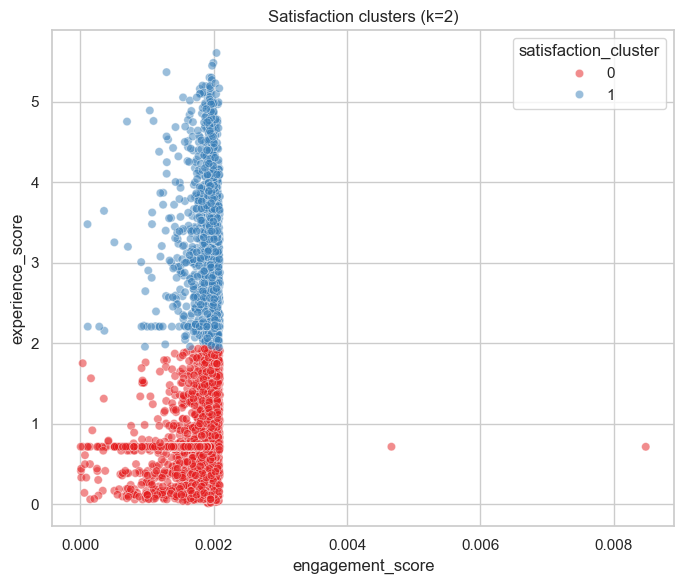

In [5]:
final_table = cluster_satisfaction_scores(satisfaction, k=2)
summary = satisfaction_cluster_summary(final_table)
display(summary)

fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(
    data=final_table.sample(min(5000, len(final_table)), random_state=42),
    x="engagement_score",
    y="experience_score",
    hue="satisfaction_cluster",
    palette="Set1",
    alpha=0.5,
    ax=ax,
)
ax.set_title("Satisfaction clusters (k=2)")
plt.tight_layout()
plt.show()

## 5. Export to MySQL

Start MySQL first: `docker compose up -d mysql` or `make mysql-up`

In [6]:
rows_exported = export_satisfaction_scores(final_table)
print(f"Exported {rows_exported:,} rows to MySQL table user_satisfaction_scores")

# Screenshot this output for your submission
verify_mysql_export(limit=10)

Exported 106,856 rows to MySQL table user_satisfaction_scores


,customer_id,engagement_score,experience_score,satisfaction_score,satisfaction_cluster
0,3.360100e+10,0.001971,0.583872,0.292922,0
1,3.360100e+10,0.000948,0.170083,0.085516,0
2,3.360100e+10,0.001877,0.715645,0.358761,0
3,3.360101e+10,0.001986,1.649378,0.825682,0
4,3.360101e+10,0.002078,2.732597,1.367338,1
5,3.360101e+10,0.001691,0.528493,0.265092,0
6,3.360101e+10,0.001908,2.315336,1.158622,1
7,3.360101e+10,0.001844,0.752160,0.377002,0
8,3.360101e+10,0.001603,0.715669,0.358636,0
9,3.360102e+10,0.001933,1.031736,0.516835,0
